# 650 nm eye-illumination experiment

## tl;dr

This executed notebook reproduces the reduced-eye sweep, loads the real OpticStudio 24.1 cross-validation, and exposes the assumptions needed to interpret the source-size recommendations. The model is paraxial and radiometrically normalized; it does not establish retinal exposure safety.

## Context & Methods

### Key Assumptions

- A rotationally symmetric effective thin eye lens represents each eye.
- Accommodation changes eye power while retinal position remains fixed.
- A uniform circular 650 nm source is imaged onto a circular posterior-pole target.
- External lens vertex distance is 5 mm for chick and 12 mm for human eyes.
- Absolute source flux, biological scattering, diffraction, aberrations, and exposure limits are not supplied by the source PPT and are not inferred.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

ROOT = Path.cwd()
if not (ROOT / 'config' / 'experiment.json').exists():
    ROOT = ROOT.parent
RESULTS = ROOT / 'results'
FIGURES = ROOT / 'figures'
config = json.loads((ROOT / 'config' / 'experiment.json').read_text(encoding='utf-8'))
validation = json.loads((RESULTS / 'validation_report.json').read_text(encoding='utf-8'))
config['experiment_id'], validation['overall_status']

('eye-illumination-650nm-60-120d-v2', 'passed')

## Data

In [2]:
headline = pd.read_csv(RESULTS / 'headline_results.csv')
focused = pd.read_csv(RESULTS / 'focused_source_sweep.csv')
defocus = pd.read_csv(RESULTS / 'defocus_pupil_sweep.csv')
axial = pd.read_csv(RESULTS / 'axial_length_sensitivity.csv')
zos = pd.read_csv(RESULTS / 'zemax' / 'zosapi_validation.csv')
display(headline)

,eye_id,eye_label,source_demand_D,source_distance_mm,source_diameter_mm,source_area_mm2,accommodation_D,feasible_accommodation
0,chick_30_45d,30–45 day chick,60,16.666667,5.952381,27.827316,60,False
1,chick_30_45d,30–45 day chick,70,14.285714,5.102041,20.444559,70,False
2,chick_30_45d,30–45 day chick,80,12.500000,4.464286,15.652865,80,False
3,chick_30_45d,30–45 day chick,90,11.111111,3.968254,12.367696,90,False
4,chick_30_45d,30–45 day chick,100,10.000000,3.571429,10.017834,100,False
5,chick_30_45d,30–45 day chick,110,9.090909,3.246753,8.279201,110,False
6,chick_30_45d,30–45 day chick,120,8.333333,2.976190,6.956829,120,False
7,child_6y,6-year-old child,60,16.666667,5.988024,28.161575,60,False
8,child_6y,6-year-old child,70,14.285714,5.132592,20.690137,70,False
9,child_6y,6-year-old child,80,12.500000,4.491018,15.840886,80,False


## Results

### Requested 60â€“120 D source-demand sweep

The main sweep now covers 60, 70, 80, 90, 100, 110, and 120 D without an external lens. At a fixed target angular field, the required physical source diameter decreases as object distance decreases. All requested demands exceed the supplied accommodation limits.

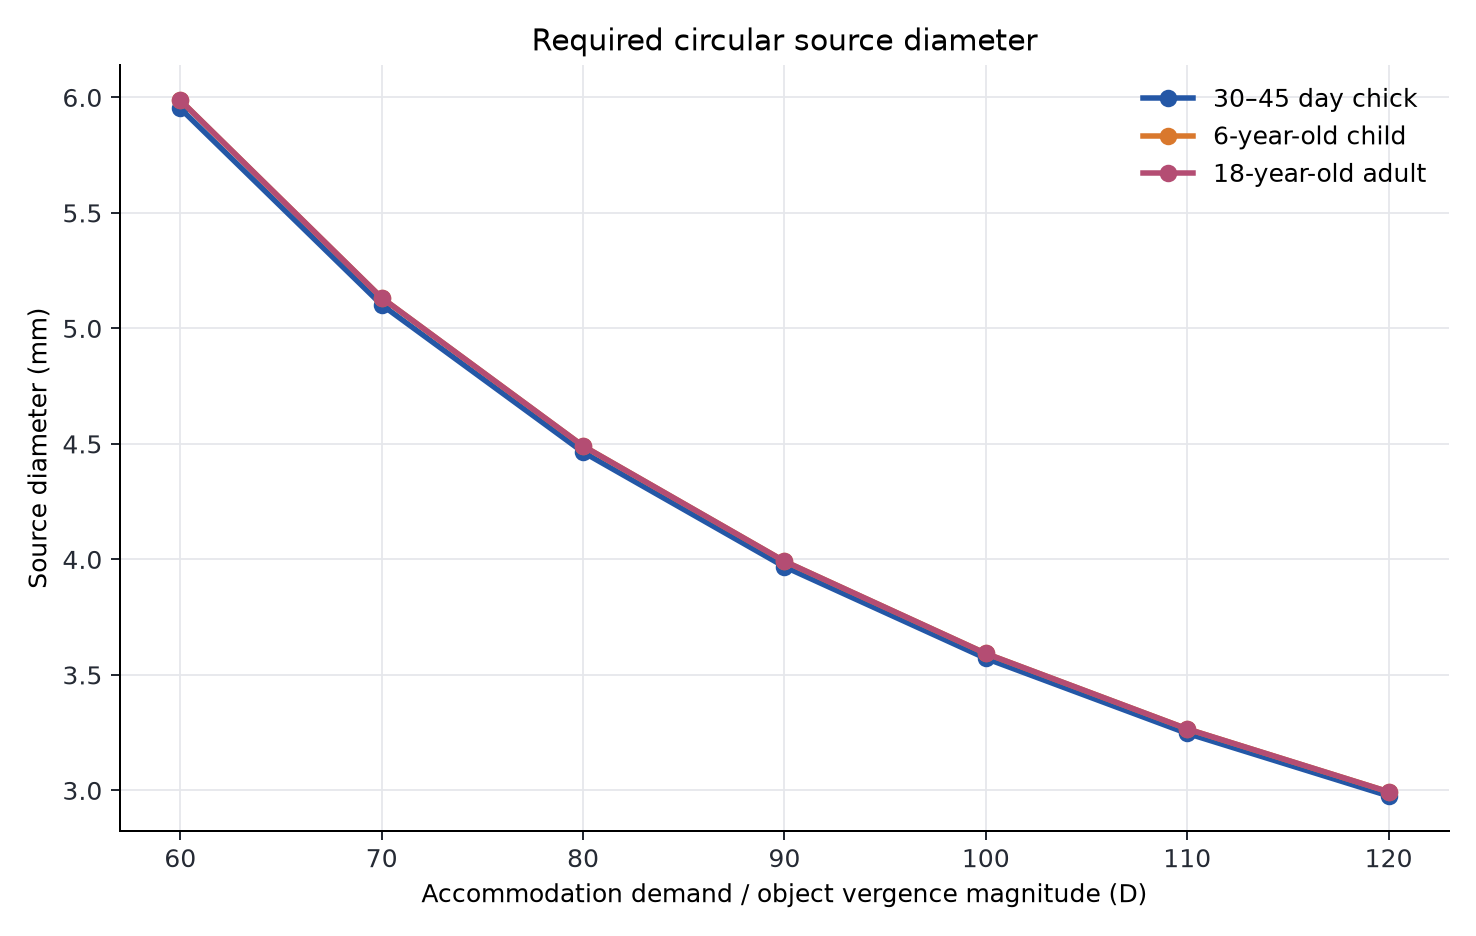

In [3]:
display(Image(filename=str(FIGURES / 'source_diameter_vs_demand.png')))

### External negative lenses consume accommodation reserve in a separate 10 D reference

The table and heatmap use the stated provisional vertex distances. A negative lens increases the positive accommodation required to focus the same physical source plane.

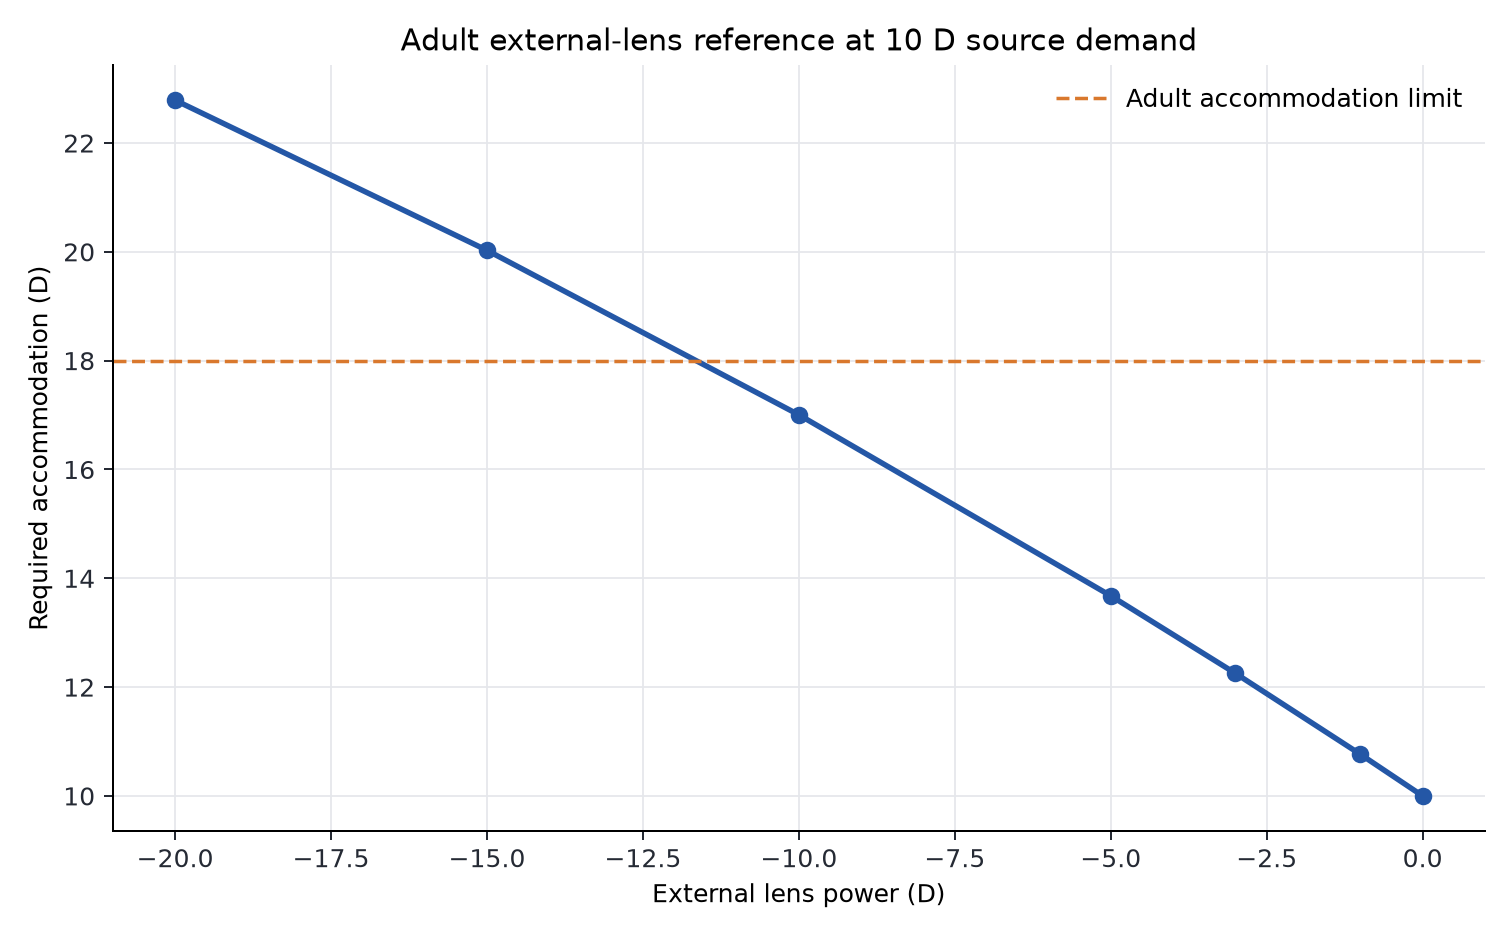

In [4]:
display(Image(filename=str(FIGURES / 'adult_accommodation_heatmap.png')))

### Defocus and pupil size jointly broaden retinal illumination

Blur-assisted geometric coverage is not equivalent to a useful focused image. Larger pupils increase the defocused footprint and reduce the source angular size needed for geometric coverage, but the optical result is less selective.

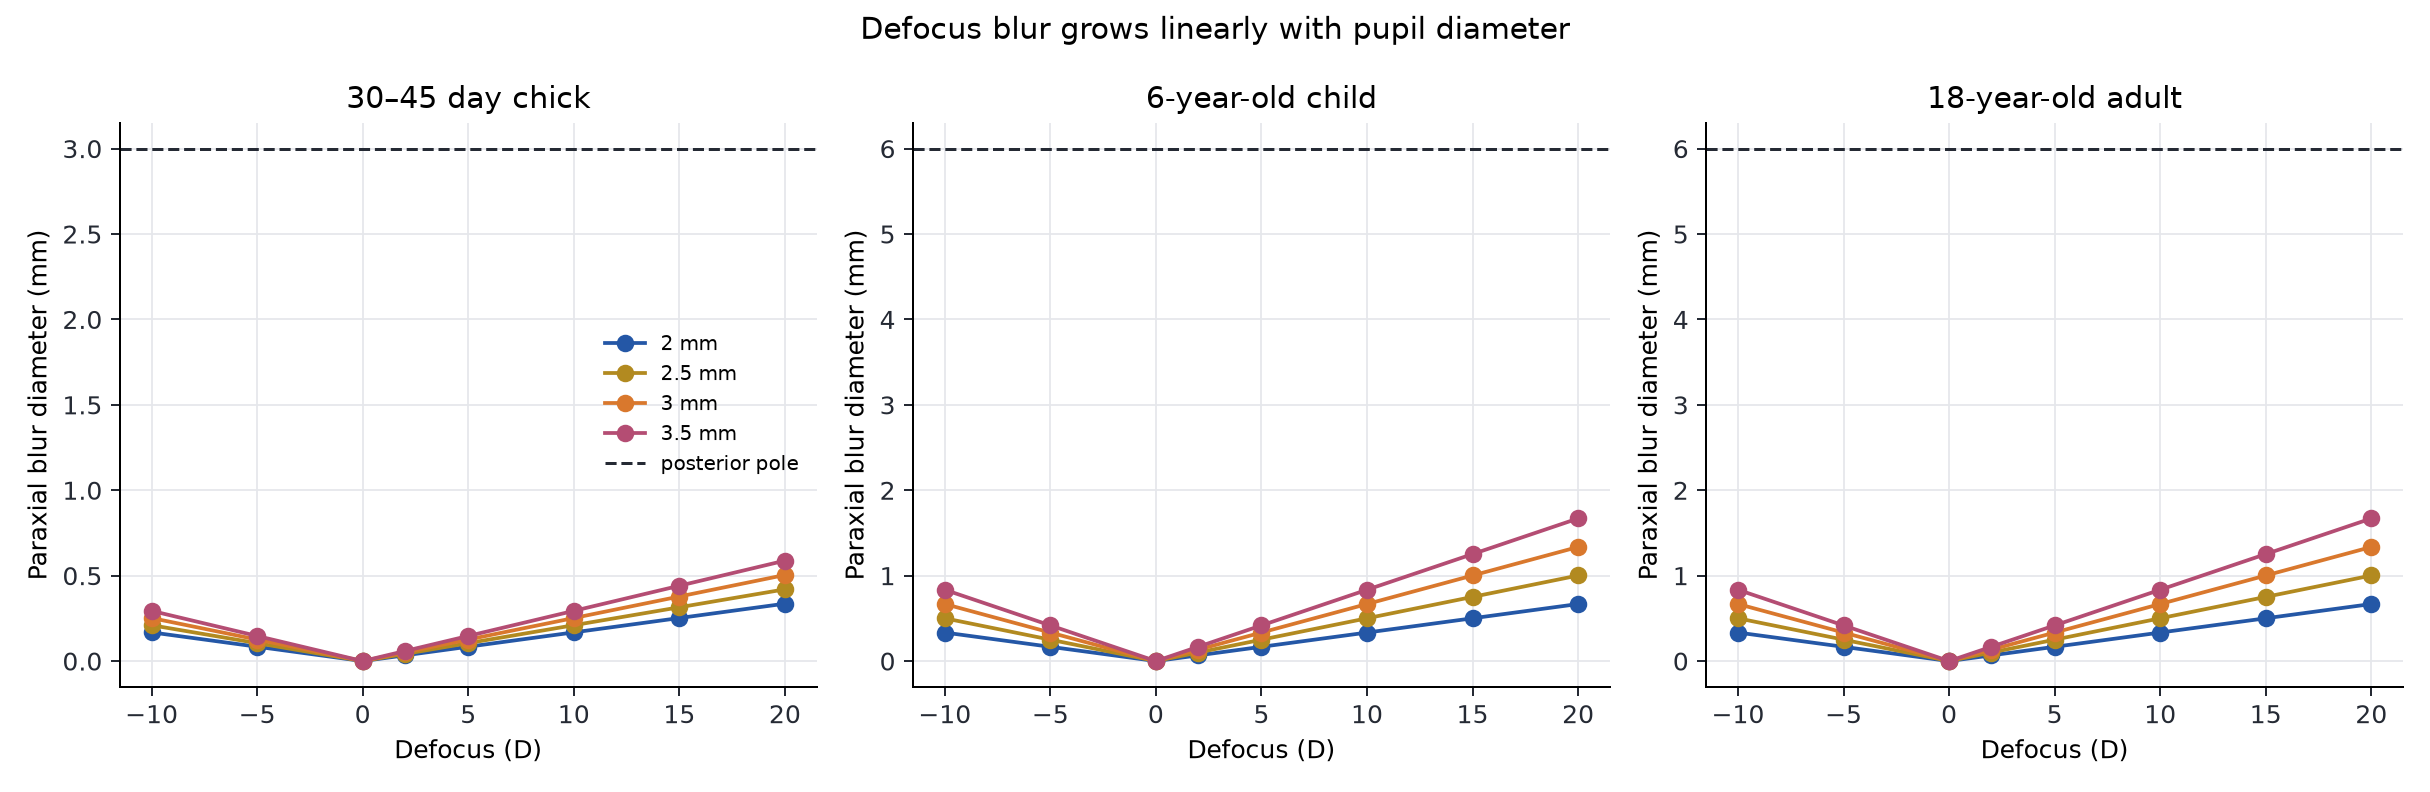

In [5]:
display(Image(filename=str(FIGURES / 'defocus_blur_by_pupil.png')))

### Real OpticStudio cross-validation

The ZOS-API validation uses OpticStudio's sequential paraxial surface and normalized real-ray batch tracing. It checks three baseline eyes, two negative-lens cases, and one deliberately unaccommodated case.

,case_id,accommodation_D,source_diameter_mm,mean_image_y_mm,rms_spread_um
0,chick_d10,10.000000,35.714286,-1.5,6.661338e-13
1,child_d10,10.000000,35.928144,-3.0,4.440892e-13
2,adult_d10,10.000000,35.928144,-3.0,4.440892e-13
3,adult_d5_ext_m5,9.182128,75.908982,-3.0,5.659307e-12
4,adult_d10_ext_m10,17.004342,39.722156,-3.0,2.519986e-12
5,adult_d10_unaccommodated,10.000000,35.928144,-3.0,2.928577e+02


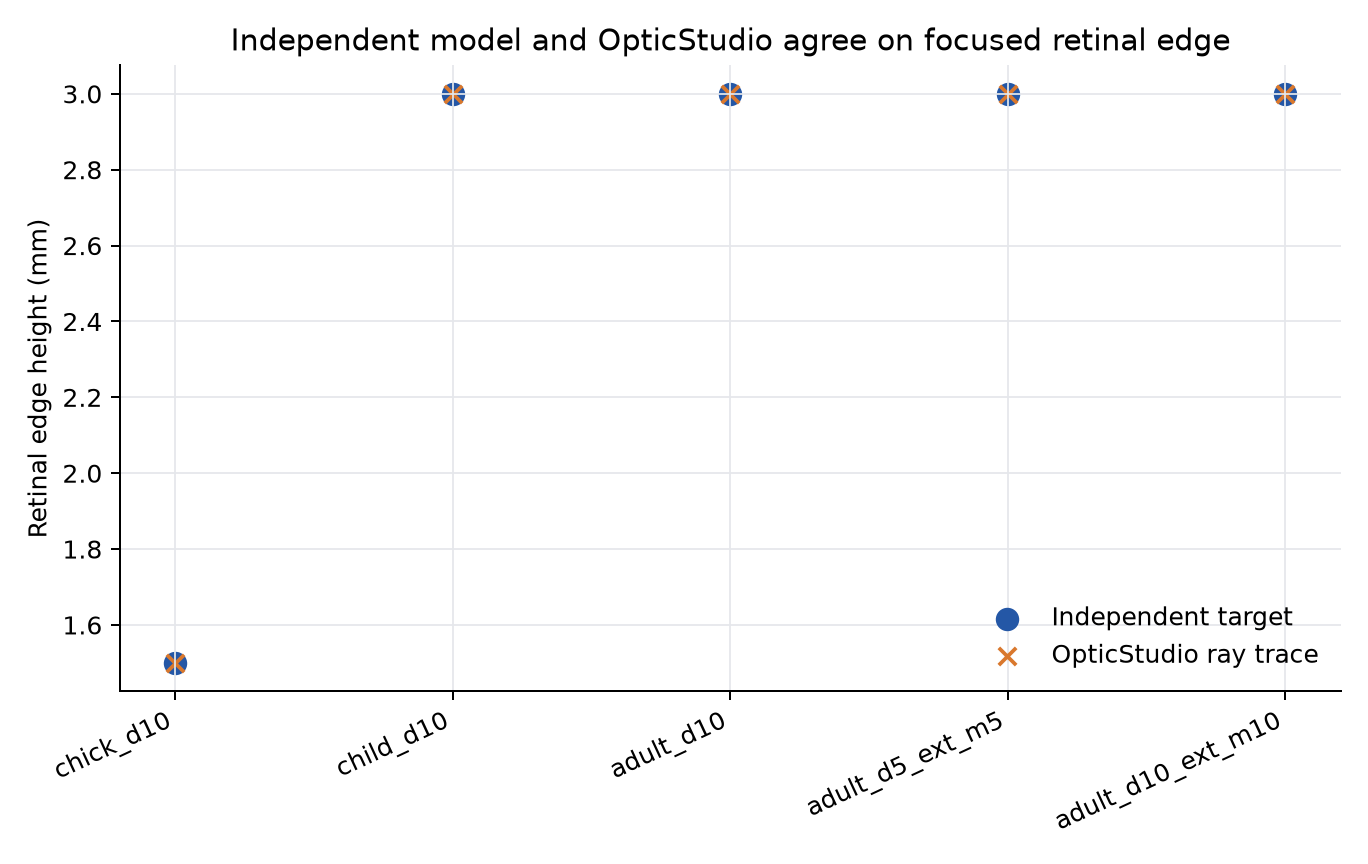

{'focused_zos_edge_max_error_um': 4.440892098500626e-13,
 'focused_zos_rms_max_um': 5.659306737752698e-12,
 'unaccommodated_expected_spread_mm': 0.82665,
 'unaccommodated_observed_spread_mm': 0.8266499999999999,
 'unaccommodated_spread_error_um': 1.1102230246251565e-13,
 'headline_rows': 21,
 'full_focused_sweep_rows': 21,
 'external_lens_reference_rows': 21,
 'source_demand_levels_D': [60.0, 70.0, 80.0, 90.0, 100.0, 110.0, 120.0],
 'source_demand_step_D': 10.0,
 'all_requested_cases_exceed_accommodation_limits': True,
 'all_imaging_residuals_below_1e_12_m': True,
 'opticstudio_version': '24.1.0',
 'api_license_valid': True,
 'overall_status': 'passed'}

In [6]:
display(zos[['case_id','accommodation_D','source_diameter_mm','mean_image_y_mm','rms_spread_um']])
display(Image(filename=str(FIGURES / 'zosapi_cross_validation.png')))
validation

## Takeaways

- All focused ZOS-API cases place the source edge on the requested retinal edge to numerical precision.
- At 60 D, the required circular source diameter is about 5.95 mm for chick and 5.99 mm for either human model; at 120 D those diameters halve to about 2.98 mm and 2.99 mm.
- Every requested 60â€“120 D case exceeds the supplied accommodation limits for chick, child, and adult models.
- The external-lens comparison remains a separate 10 D reference because 90â€“120 D object distances are shorter than the provisional 12 mm human vertex distance.
- Negative external lenses rapidly reduce the set of focusable source distances.
- These are geometric/paraxial design results, not absolute irradiance or biological-safety results. A full anatomical/GRIN and measured-QLED model is the next validation layer.